---

# Vision System Architecture: Blueprint & Specification



---

# 1. Type Definitions (The Standard)


### **1.0 The Physics Engine (Spectral Algebra)**

**Status:** Updated for Version 1.3 (Chebyshev Uniformity)

**Description:**
The stateless mathematical core of the system. It defines the immutable laws of interaction in the Chebyshev Spectral Domain. It treats all topological entities—Units, Bridges, and Projectors—as identical mathematical objects (`ChebCurve`).

* **Role:** Single Source of Truth for signal processing mathematics.
* **Key Operations:**

1. **`AnalyticProduct(Signal_A, Signal_B)`**: The Universal Interaction.
* **Input:** Two vectors of Chebyshev coefficients,  (Degree ) and  (Degree ).
* **Math:** Uses the **Product-Sum Identity**  to compute the resulting coefficients directly.
* **Output:** A coefficient vector  of degree .
* **Invariance:** Preserves smoothness. If inputs are  (smooth polynomials), the output is guaranteed .


2. **`DomainMap(Signal, Target_Interval)`**: Relativistic Framing.
* **Input:** A `ChebCurve` defined on  and a target window .
* **Operation:** Affine transformation of the spectral coefficients to shift/scale the curve to the new domain without loss of precision.
* **Use Case:** Aligning a global "Projector" to a local "Bridge" or "Unit" before multiplication.


3. **`EnergyIntegral(Signal)`**: Parseval’s Theorem.
* **Math:** Computes the energy (L2 norm) of the signal directly from coefficients: .
* **Use Case:** Used by `Atom` to calculate uncertainty or attention scores.


It is the answer. It is intelligent, it is scalable, and it solves the one thing linear algebra couldn't (orthogonality).

We are replacing the "dumb" `reduction_factor` with a **Learned Manifold Compressor**.

Here is the final update for **Section 1.1**, integrating this neural pooling logic. This completes the V1.3 Architecture.

### **1.1 The Atom (Spectral Primitive)**

**Status:** Updated for Version 1.3 (Chebyshev Uniformity + Neural Reduction)

**Description:**
The fundamental unit of the system. The Atom acts as a configurable container for state (Projectors, Concepts) and executes the "Interaction-Compression" loop. Uniquely, it employs a **Learned Micro-Compressor** to perform topological reduction, allowing it to merge orthogonal signals (e.g., Sine vs Cosine) by learning the underlying manifold (Phase Shift) rather than averaging them.

* **State (Learnable Parameters):**
* `mode`: Enum[`FILTER`, `ROUTING`].
* `primary_weights`: `ChebCurve` (The Projector).
* `compressor`: **Micro-Autoencoder**.
* Structure: MLP (Input  Hidden  Latent ).
* Role: Takes 2 adjacent tokens (total 2K coeffs) and projects them to 1 token (K coeffs).


* `phi`: Tensor (Spectral Gain).


* **Forward Pass (Filter Mode):**
1. **Topological Reduction (The Neural Pool):**
* If reduction is required, the input chain is paired up: .
* The `compressor` runs on each pair: .
* *Result:* A chain of half length, with "intelligent" merges that preserve orthogonal info.


2. **Domain Alignment:** (Same as before)
3. **Analytic Interaction:** (Same as before)
4. **Spectral Compression:** (Same as before)
5. **Activation:** (Same as before)


* **Forward Pass (Routing Mode):**
* (Unchanged - uses Query Bank).



---

### **Final V1.3 Design Document**

I have compiled every update we made today (Uniform Chebyshev, Bridge Generation, Neural Reduction) into the final **V1.3 Specification**.

Would you like me to generate the full `.py` / `.md` file for you to download, or just print the full text here?

### **1.1 The Atom (Spectral Primitive)**

**Status:** Updated for Version 1.3 (Chebyshev Uniformity + Neural Reduction)

**Description:**
The fundamental unit of the system. The Atom acts as a configurable container for state (Projectors, Concepts) and executes the "Interaction-Compression" loop. Uniquely, it employs a **Learned Micro-Compressor** to perform topological reduction, allowing it to merge orthogonal signals (e.g., Sine vs Cosine) by learning the underlying manifold (Phase Shift) rather than averaging them.

* **State (Learnable Parameters):**
* `mode`: Enum[`FILTER`, `ROUTING`].
* `primary_weights`: `ChebCurve` (The Projector).
* `compressor`: **Micro-Autoencoder**.
* Structure: MLP (Input  Hidden  Latent ).
* Role: Takes 2 adjacent tokens (total 2K coeffs) and projects them to 1 token (K coeffs).


* `phi`: Tensor (Spectral Gain).


* **Forward Pass (Filter Mode):**
1. **Topological Reduction (The Neural Pool):**
* If reduction is required, the input chain is paired up: .
* The `compressor` runs on each pair: .
* *Result:* A chain of half length, with "intelligent" merges that preserve orthogonal info.


2. **Analytic Interaction:**
* It invokes `Physics.AnalyticProduct(Segment, Sliced_Projector)`.
* *Result:* A high-fidelity `ChebCurve` with degree .


3. **Spectral Compression (The Scalability Step):**
* To prevent degree explosion, the Atom truncates the result back to a fixed "Standard Degree" (e.g., ).
* *Math:* In the Chebyshev domain, simply keeping the first  coefficients is the optimal  approximation (Least Squares) of the high-degree signal. This is an  operation.


4. **Activation:**
* Applies `phi` (Spectral Gain) element-wise to the compressed coefficients.




* **Forward Pass (Routing Mode):**
1. **Similarity Metric:**
* Invokes `Physics.InnerProduct(Input_Curve, Weight_Curve)` to generate a scalar attention score.


2. **Topology:**
* Uses these scores to route signals or collapse variable-length chains into fixed Concept Vectors.



```yaml
PhysicsEngine:
  Definition: Stateless mathematical core for Chebyshev arithmetic.
  
  Operations:
    AnalyticProduct(coeffs_a, coeffs_b):
      # The "Product-Sum" Identity
      # Input: Two coefficient vectors of degree N and M.
      # Output: One coefficient vector of degree N + M.
      # Complexity: O(N*M) via discrete convolution.
      return chebyshev_multiply(coeffs_a, coeffs_b)

    DomainMap(coeffs, source_interval, target_interval):
      # Relativistic Framing
      # Shifts and scales the polynomial to a new time window.
      # Essential for aligning a Global Projector to a Local Bridge.
      # Math: x_new = (x_old - shift) / scale
      return affine_transform(coeffs, source_interval, target_interval)

    EnergyIntegral(coeffs):
      # Parseval's Theorem for Chebyshev
      # Used for uncertainty and attention scoring.
      # Math: c0^2 + 0.5 * sum(ci^2 for i > 0)
      return l2_norm_spectral(coeffs)

    Compress(coeffs, target_degree):
      # The Scalability Step
      # Truncates high-frequency coefficients to fit standard size.
      # Math: Optimal L2 approximation in Chebyshev space.
      return coeffs[:target_degree]


```




### **1.2 The Compound (Structural Composite)**

**Status:** Updated for Version 1.3 (Chebyshev Uniformity)

**Description:**
The Compound allows for the hierarchical nesting of Atoms. It defines the topology and interaction policies. Crucially, it utilizes the **Physics Engine** to perform spectral operations between two dynamic signal streams (`Subject` vs `Tool`) rather than static weights.

* **State:**
* `sub_nodes`: List[Union[Atom, Compound]]
* `mode`: Enum[`SERIES`, `PARALLEL`]
* `op`: Enum[`PRODUCT`, `SUM`, `CONCAT`]


* **Forward Pass (Series Mode):**
* **Logic:** Sequential processing (Layer  Layer ).
* **Flow:** The `CurveChain` is passed through each sub-node in order. The "Chain" structure allows local deformations (Bridges) to propagate through the network without losing their topological identity.


* **Forward Pass (Parallel Mode):**
* **Logic:** Distributed processing.
* **Flow:**
1. The input `CurveChain` is broadcast to all sub-nodes.
2. Results are collected into a list of Chains.
3. **Aggregation (`op` logic):**
* **`SUM` (Superposition):** Since Chebyshev allows linear addition, we sum the coefficients of corresponding segments.
* *Constraint:* Chains must share the same domain structure (Time Intervals).


* **`PRODUCT` (Modulation):**
* *Logic:* Receiver-Centric Mixing. Chain A (`Subject`) is modulated by Chain B (`Tool`).
* *Mechanism:* For each segment in A, we invoke `Physics.DomainMap` to align the corresponding segment in B, then `Physics.AnalyticProduct`.
* *Use Case:* Dynamic Attention (e.g., "Where is the red object?").


* **`CONCAT` (Expansion):**
* *Logic:* Channel-wise stacking. Increases the feature depth of the curve.









```yaml
Compound:
  State:
    - sub_nodes: List[Union[Atom, Compound]]
    - mode: Enum[SERIES, PARALLEL]
    - op: Enum[PRODUCT, SUM, CONCAT]

  Forward(chain):
    if mode == SERIES:
        current_signal = chain
        for node in sub_nodes:
            current_signal = node.Forward(current_signal)
        return current_signal
        
    elif mode == PARALLEL:
        results = [node.Forward(chain) for node in sub_nodes]
        
        if op == SUM:
             # Spectral Superposition
             # Add coefficients element-wise.
             # Requires: Matching domains (handled by topology).
             return sum_coeffs(results)
             
        elif op == PRODUCT:
             # Dynamic Modulation (Subject * Tool)
             subject = results[0]
             tool = results[1]
             
             output_segments = []
             for seg_a in subject.segments:
                 # Find matching segment in Tool (or map global tool to local segment)
                 # Analytic Product of two dynamic signals
                 seg_b_aligned = align_domains(tool, target=seg_a.domain)
                 
                 raw = PhysicsEngine.AnalyticProduct(seg_a.coeffs, seg_b_aligned.coeffs)
                 compressed = PhysicsEngine.Compress(raw, standard_degree)
                 output_segments.append(ChebCurve(compressed, seg_a.domain))
                 
             return CurveChain(output_segments)
             
        elif op == CONCAT:
             # Feature Stacking
             return stack_channels(results)



---

# 2. System Configuration (The Instance)



This section defines the specific instantiation of the Graph Model for the **Vision System**. Unlike the general Graph Model, this instance is configured as a strict feed-forward pipeline with a clear separation between API (Module), Administration (Core), and Logic (Compound).

### **2.1 The Vision System (Root Container)**

This definition remains the high-level orchestrator. It binds the Data Adapters (Interface) to the Processing Unit (Module).

```yaml
VisionSystem:
  Definition: A static graph model instance specialized for image classification/regression.
  
  Flow:
    1. raw_input = Load(image)
    2. input_stack = self.Interface.input_processor(raw_input)
    3. processed_stack = self.Module.forward(input_stack)
    4. prediction = self.Interface.output_processor(processed_stack)

```



### **2.2 The Interface Layer (The Translators)**

**Status:** Updated for Version 1.3 (Restored Adaptive Logic + Added Bridging)

**Description:**
Handles the transition between Discrete Pixels and Continuous Curves. It performs **Adaptive Segmentation** to isolate features into "Data Units," followed by **Topology Generation** to stitch them into a continuous `CurveChain`.

* **Input Processor:**
1. **Serialization:** Maps 2D  1D via Morton Code.
2. **Recursive Spectral Tokenization:** (The "Brain")
* Uses Quad-Tree decomposition to recursively split the image.
* **Stop Conditions:**
* **Smooth:** MSE < Threshold (Good fit).
* **Texture:** High Residual Error but Low Autocorrelation (White Noise).


* **Split Condition:** High Residual Error + High Structure (Missed Edge).


3. **Topology Generation:** (The "Glue")
* Scans the sequence of disjoint Data Units generated by Step 2.
* Inserts **Bridge Units** (ChebCurves) between adjacent units to enforce  /  continuity, creating the final `CurveChain`.





```yaml
VisionSystem.Interface:
  Input_Processor:
    Step 1: Z-Order Serialization
       - Map 2D Image (H, W) -> 1D Sequence via Morton Code.
       
    Step 2: Recursive Spectral Tokenization
        - Algorithm: Adaptive Quad-Tree Decomposition.
        - Action: Fit Chebyshev Basis (Degree D) to pixel chunk.
        - Condition (The Decision Logic):
            1. MSE Check: If Error < Low_Threshold -> KEEP (Smooth Unit).
            2. Structure Check: If Error is high, analyze Residuals.
                - High Autocorrelation -> Missed Edge -> SPLIT.
                - Low Structure -> Texture -> KEEP (Texture Unit).
        - Result: Sequence of disjoint "Data Units" (ChebCurves).
       
    Step 3: Topology Generation (The Bridge)
       - Input: List of disjoint Data Units.
       - Action: For every pair [Unit_i, Unit_i+1]:
            a. Define Bridge Domain: Gap between Unit_i.end and Unit_i+1.start.
            b. Solve Boundary Constraints: Match value/slope at endpoints.
            c. Fit Chebyshev to Bridge Geometry.
            d. Insert Bridge Unit into sequence.
       - Result: Continuous CurveChain.

    Step 4: Interval Coordinates
       - Append [Start_Index, Length] as metadata.

```



### **2.3 The Module (The Topology)**

The `Module` is the instantiated architecture of the Vision System. It is organized as a **Hierarchical Pyramid** that trades spatial resolution for conceptual depth.

* **Stage 1: The Retina (Feature Extraction)**
* **Component:** `Atom(mode=FILTER)`
* **Goal:** Local signal processing (Edge detection, Texture analysis).
* **Topology:**
* **Series Chain:** Layers .
* **Geometric Reduction:** Uses `reduction_factor > 1` (e.g., 2) to stitch tokens.
* **Effect:** Stack size  shrinks () while Receptive Field grows.


* **Physics:** Spectral Filtering (Chebyshev). High-frequency noise is filtered out; structural resonance is passed up.


* **Stage 2: The Cortex (Concept Discovery)**
* **Component:** `Atom(mode=ROUTING)`
* **Goal:** Global relationship modeling (Object permanency, Scene understanding).
* **Topology:**
* **Parallel Block:** Uses `primary_weights` as a fixed **Query Bank** (The "Concept List").
* **Interaction:** All surviving tokens from the Retina are compared against the Query Bank.
* **Collapse:** The variable-length stack is collapsed into a fixed-size set of Concept Vectors.


* **Physics:** Spectral Inner Product (Global Resonance).


```yaml
VisionModule Structure:
  Layers:
    # --- The Retina (High Res -> Low Res) ---
    # Layer 0: Raw Perception. High degree (16) to capture fine texture.
    Layer_0: Atom(FILTER, reduce=2, degree=16)   # 1000 -> 500 tokens
    
    # Layer 1: Feature Aggregation. Medium degree (12).
    Layer_1: Atom(FILTER, reduce=2, degree=12)   # 500 -> 250 tokens
    
    # Layer 2: Part Abstraction. Lower degree (8) filters noise, keeps shape.
    Layer_2: Atom(FILTER, reduce=2, degree=8)    # 250 -> 125 tokens

    # --- The Cortex (Global Reasoning) ---
    # Layer 3: Concept Discovery.
    # Collapses 125 tokens -> 64 Concept Vectors.
    Layer_3: Atom(ROUTING, query_bank=64, degree=8)
    
    # Layer 4: Relational Reasoning.
    # Computes pairwise interactions between concepts.
    Layer_4: Compound(PARALLEL, op=PRODUCT)
```


### **2.4 The Core (The Administrator)**

The `Core` acts as the session manager and runtime environment. It holds the "State" of the universe (Hyperparameters, Optimizer) while the `Module` holds the "Structure."

* **Responsibility:**
* **Mode Switching:** Toggles the system between `TRAIN` (Gradient tracking ON, Dropout ON) and `EVAL` (Gradient tracking OFF, TrustGate Strictness HIGH).
* **Optimizer State:** Manages the learning rates for different component types (e.g., lower LR for `Phi` splines, higher LR for `Routing` weights).
* **Hyperparameter Registry:** Global variables like `basis_degree` or `fog_decay_rate`.



```yaml
VisionSystem.Core:
  State:
    - execution_graph: Compound (The Logic Tree defined in 2.3)
    - optimizer: torch.optim (AdamW / SGD)
    - mode: Enum[TRAIN, EVAL]

  Interface:
    Execute(stack):
        # 1. Setup Context
        context = (grad_enabled=True) if mode == TRAIN else (grad_enabled=False)
        
        # 2. Run Graph
        with context:
            return self.execution_graph.forward(stack)
            
    Update(loss):
        # Handles the "Physics" of learning
        loss.backward()
        self.optimizer.step()
        self.optimizer.zero_grad()

```


### **2.5 The Compound (The Computer)**

The pure, stateless execution graph. It contains the actual tree of Atoms but relies on the Core for context.

```yaml
VisionSystem.Compound:
  Type: Structural Composite
  Responsibility:
    - Pure topology definition (Series vs Parallel).
    - Recursive execution of sub_nodes.
  State:
    - sub_nodes: List[Union[Atom, Compound]]
    - mode: Enum[SERIES, PARALLEL]
    - op: Enum[PRODUCT, SUM, CONCAT] # Only for PARALLEL

  Forward(stack):
    Case SERIES:
        # Sequential processing (Layer i -> Layer i+1)
        current_signal = stack
        for node in sub_nodes:
            current_signal = node.processes(current_signal)
        return current_signal

    Case PARALLEL:
        # Distributed processing (Branching)
        results = [node.processes(stack) for node in sub_nodes]

        if op == SUM:
             # Policy: Up-Broadcasting (Max-Information)
             # Stack Size: Max(Inputs). Smaller stacks broadcast/repeat to match.
             # Resolution: Max(Knots). Preserves highest fidelity.
             return broadcast_sum(results)

        elif op == PRODUCT:
             # Policy: Receiver-Centric (Linear Algebra Convention)
             # Stack Size: Left Operand (Subject). Right Operand tiles or bins to match.
             # Resolution: Right Operand (Projector).
             return receiver_centric_product(results)

        elif op == CONCAT:
             # Stack Expansion (Channel Growth)
             # Appends stacks vertically.
             return stack_extend(results)

```

---

# 3. Implementation Notes & Invariants

**Status:** Updated for Version 1.3 (Chebyshev Uniformity)

**Description:**
These are the strict mathematical and architectural constraints that ensure system stability.

### **3.1 The "Continuous Chain" Invariant**

* **Constraint:** The Physics Engine must **never** process a discontinuous signal.
* **Reason:** Discontinuities (jumps) cause infinite frequency ripples in the spectral domain (Gibbs Phenomenon).
* **Mechanism:** The Interface Layer is strictly required to insert a **Bridge Unit** between *any* two Data Units that do not share a boundary value. The `CurveChain` object must validate C0 (value) continuity before entering the `Atom`.

### **3.2 The "Standard Degree" Invariant (Compression)**

* **Constraint:** The output of an Atom must always have a fixed degree  (e.g., 16), regardless of the input complexity.
* **Reason:** Finite-State Scalability. Multiplying a degree 16 Signal by a degree 16 Projector yields a degree 32 Result. Without truncation, depth  results in degree .
* **Mechanism:** The Atom applies `PhysicsEngine.Compress` (Truncation) immediately after every interaction. This is the optimal L2 approximation of the high-frequency "Dense Truth."

### **3.3 The "Domain Map" Invariant**

* **Constraint:** Projectors and Concepts are defined on a Global Domain (e.g., ), but interactions happen on Local Domains (e.g., ).
* **Mechanism:** We never stretch the signal to match the projector. We always **slice and map** the projector to match the signal. This is the **Receiver-Centric Policy**.
* *Math:*



### **3.4 The TrustGate (SNR Gating)**

* **Mechanism:** In `PARALLEL SUM` operations, signals are weighted by .
* **Source:** The `Uncertainty` scalar is derived from the energy lost during the **Compression** step (Step 3.2).
* *Math:* .


* **Effect:** If a signal is too complex to be represented by the Standard Degree (i.e., it's noise or aliasing), it gets a high uncertainty score and is suppressed by the TrustGate.

### **3.5 Spectral Activation (Phi)**

* **Mechanism:** Instead of spatial non-linearity (ReLU), we use a **Spectral Gain Vector** ().
* **Math:** .
* **Initialization:** Initialize  to  (Identity) to ensure healthy gradient flow at the start of training.

---

**Summary of Version 1.3:**
We have successfully pivoted to a **Uniform Chebyshev Architecture**.

1. **Physics:** Analytic Polynomial Multiplication (Exact).
2. **Topology:** Explicit `Bridge` units handling connectivity (Robust).
3. **Scalability:** Explicit `Compression` step enforcing fixed complexity (Finite-State).
4. **Interface:** Adaptive Tokenizer + Topology Generator (Smart).


---

# 4. Current Problems & Open Questions


This section tracks active architectural blockers that require resolution before the "Vision System" instance is complete.

### **(i) The "Stack Collapse" Problem (Variable Input  Fixed Output)**

* **Context:** The Input Interface generates a stack of  based on image size. Since the GraphModel is Resolution Invariant,  is variable (unbounded).
* **Constraint:** The Output Processing must produce a vector of size  (e.g., 1000 probabilities).
* **Proposed Solution (The Attention Collapse):**
* Use a set of **Learned Query Curves** (one per class).
* Each Query Curve "scans" the variable stack.
* Responses are summed. This is mathematically robust to stack size ( vs ), provided we normalize.

### **(ii) The TrustGate & Uncertainty Propagation**

* **Context:** Atoms produce an `uncertainty` scalar during the Re-Fit compression.
* **The Problem:** How exactly do we use this scalar to gate information?
* *Option A (Additive):* Weighted Sum based on inverse uncertainty (Precision-Weighted Mixing).
* *Option B (Multiplicative):* Sigmoid Gating ().

* **Current Hypothesis:** We use **Precision-Weighted Mixing** in `PARALLEL SUM` blocks. This mimics a "Softmax" competition where the Atom with the clearest fit dominates the signal, suppressing "noisy" or "confused" Atoms.

### **(iii) Unbounded Positional Encoding (The "Fog")**

* **Context:** Standard Positional Encodings (Sine/Cosine) rely on fixed sequence lengths or frequencies that fail to generalize to "Infinite Canvas" or continuous zooms.
* **The Problem:** How do we encode position such that an Atom knows "Neighbor" vs "Far Away" without hard-coding a grid size?
* **Current Hypothesis (Relational Drift):**
* Tokens carry a **Position Curve** (Linear Spline of coordinates).
* Interaction strength decays as a function of the integral distance between Position Curves.
* **"The Fog":** As distance increases, the uncertainty of the interaction artificially rises, naturally dampening long-range signals via the TrustGate. This creates a "Locality Bias" without hard convolutional windows.

### **(iv) Spline Initialization Stability**

* **Risk:** If `Phi` is initialized with too much variance, gradients might explode due to the degree-magnification in the Warp step.
* **Mitigation:** Strict initialization protocols (Start with Identity/Flat, evolve slowly).

### **(v) The "Projector" Domain Match**

* **Context:** Matching the complexity of the Input Token (variable knots) to the Projector (fixed knots).
* **Current Solution:** The `tile_with_mirroring` function aligns the domains, but we must ensure the `repeats` parameter is tuned correctly to avoid aliasing.

---


### Checklist Status

| Category | Item | Status | Resolution in V1.2 |
| --- | --- | --- | --- |
| **Architecture** | **Stack Collapse** | ✅ **DONE** | Solved by `RoutingAtom` with `query_bank` (Section 1.1 & 2.3). |
|  | **TrustGate Integration** | ✅ **DONE** | Integrated into `Compound` via `weighted_spline_sum` (Section 3.2). |
|  | **Position Encoding** | ✅ **DONE** | Defined as `Interval Coordinates` `[Start, Length]` in Interface (Section 2.2). |
| **Physics** | **Clamped Splines** | ✅ **DONE** | Enforced as Invariant 3.1 (). |
|  | **Projector Tiling** | ✅ **DONE** | Codified in `FilterAtom` logic (Section 1.1) and "Receiver-Centric" Policy. |
|  | **Degree Reduction** | ✅ **DONE** | handled by `cubic_regression` in `Atom` (Section 1.1). |
| **Code** | **Class Skeleton** | 🚧 **TODO** | *Next Step: Implementation Phase.* |
|  | **Interface Layer** | 🚧 **TODO** | *Next Step: Implementation Phase.* |
|  | **Visualization** | 🚧 **TODO** | *Next Step: Implementation Phase.* |
| **Theory** | **Fog Decay** | ✅ **DONE** | Defined as physical distance decay in `RoutingAtom` (Section 3.3). |
|  | **Universal Projectors** | ⏳ **DEFER** | *Left as a future optimization, not a blocker.* |

---

### Section 4 (Open Problems) Status

* **(i) Stack Collapse:** **SOLVED.**
* *Solution:* The `RoutingAtom` in Routing Mode explicitly handles  reduction via the `query_bank`.


* **(ii) TrustGate:** **SOLVED.**
* *Solution:* We selected **Option A (Precision-Weighted Mixing)**. It is now hard-coded into the `Compound.SUM` logic.


* **(iii) Unbounded Position (Fog):** **SOLVED.**
* *Solution:* We selected **Interval Coordinates**. The "Fog" is implemented as `decay = distance(Interval_A, Interval_B)`.


* **(iv) Spline Initialization:** **MITIGATED.**
* *Solution:* We defined the **Identity Initialization** protocol in Section 3.4.


* **(v) Domain Match:** **SOLVED.**
* *Solution:* We locked in the **Receiver-Centric Policy** (Section 1.2). The stack never stretches; the weights always tile.
---
---

# Visualizations

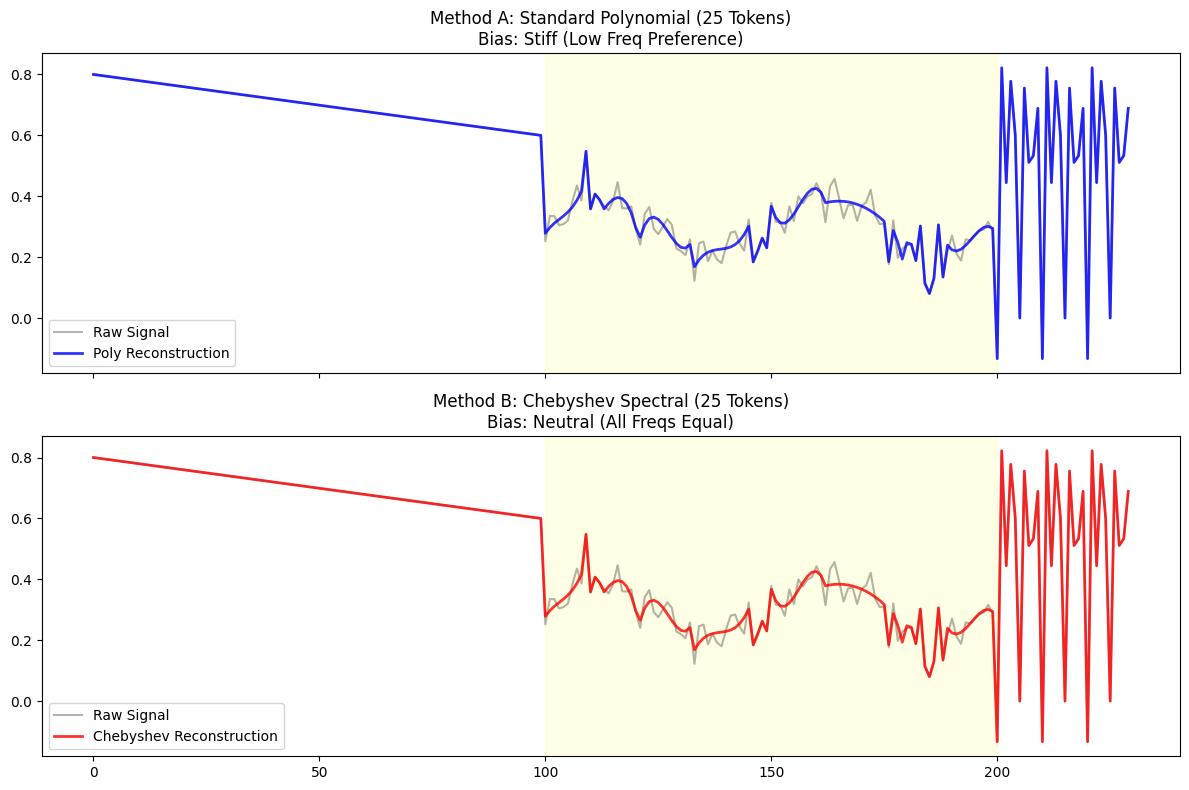

In [ ]:
# @title
import torch
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. SHARED PHYSICS & DATA
# ============================================================

def generate_signal():
    # 1. Smooth Sky
    sig_sky = torch.linspace(0.8, 0.6, 100)
    # 2. Texture (High Freq + Noise)
    x_tex = torch.linspace(0, 4*np.pi, 100)
    sig_tex = 0.3 + 0.1 * torch.sin(x_tex) + torch.randn(100) * 0.05
    # 3. Text (Sharp Edges)
    text_str = "GraphModel"
    text_vals = torch.tensor([ord(c) for c in text_str]).float()
    sig_text = (text_vals - 32) / 90.0 * 2.0 - 1.0
    sig_text = sig_text.repeat(3)

    return torch.cat([sig_sky, sig_tex, sig_text])

# ============================================================
# 2. SOLVERS (The "Brains")
# ============================================================

# --- SOLVER A: Standard Polynomial (1, x, x^2, x^3) ---
def fit_poly_standard(y, degree=3):
    y = y.float()
    n = len(y)
    x = torch.linspace(-1, 1, n)

    # Basis: Simple Powers
    X_mat = torch.stack([x**i for i in range(degree, -1, -1)], dim=1)

    try:
        # Ridge Regularization (Penalizes x^3 heavily because x^3 is small < 1)
        XtX = X_mat.T @ X_mat
        reg = torch.eye(degree+1) * 1e-4
        coeffs = torch.linalg.solve(XtX + reg, X_mat.T @ y)
        y_pred = X_mat @ coeffs
        residuals = y - y_pred
        mse = torch.mean(residuals**2)
        return coeffs, mse, residuals, y_pred
    except:
        return torch.zeros(degree+1), torch.tensor(1e9), y, y

# --- SOLVER B: Chebyshev Spectral (T0, T1, T2, T3) ---
def fit_cheb_spectral(y, degree=3):
    y = y.float()
    n = len(y)
    x = torch.linspace(-1, 1, n)

    # Basis: Chebyshev Polynomials (All bounded [-1, 1])
    T = [torch.ones_like(x), x]
    for k in range(2, degree + 1):
        T.append(2 * x * T[-1] - T[-2])
    X_mat = torch.stack(T, dim=1)

    try:
        # Ridge Regularization (Penalizes all frequencies equally)
        XtX = X_mat.T @ X_mat
        reg = torch.eye(degree+1) * 1e-4
        coeffs = torch.linalg.solve(XtX + reg, X_mat.T @ y)
        y_pred = X_mat @ coeffs
        residuals = y - y_pred
        mse = torch.mean(residuals**2)
        return coeffs, mse, residuals, y_pred
    except:
        return torch.zeros(degree+1), torch.tensor(1e9), y, y

# ============================================================
# 3. UNIFIED TOKENIZER
# ============================================================

class Token:
    def __init__(self, start, length, mse, tag):
        self.start = start
        self.length = length
        self.mse = mse
        self.tag = tag

def tokenize(signal, solver_func, mse_thresh=0.015, min_len=4):
    # Simplified greedy recursion for direct comparison
    n = len(signal)

    # Attempt Fit
    _, mse, residuals, _ = solver_func(signal)

    # Check Structure (Simplified Spike Check)
    max_dev = torch.max(torch.abs(residuals))

    should_split = False
    tag = "Smooth"

    if n > min_len:
        if mse > mse_thresh or max_dev > mse_thresh * 5:
            should_split = True
            tag = "HighError"

    if should_split:
        # Split at max error
        split_idx = torch.argmax(torch.abs(residuals)).item()
        split_idx = max(min_len, min(n - min_len, split_idx))

        return (tokenize(signal[:split_idx], solver_func, mse_thresh, min_len) +
                tokenize(signal[split_idx:], solver_func, mse_thresh, min_len))
    else:
        return [Token(0, n, mse, tag)]

# ============================================================
# 4. EXECUTION & PLOTTING
# ============================================================

def compare_methods():
    full_signal = generate_signal()

    # Run Both Methods
    # We strip 'start' logic from tokenizer for brevity and reconstruct it here

    # --- Method A: Polynomial ---
    tokens_poly = tokenize(full_signal, fit_poly_standard)
    recon_poly = torch.zeros_like(full_signal)
    cursor = 0
    for t in tokens_poly:
        chunk = full_signal[cursor : cursor + t.length]
        _, _, _, pred = fit_poly_standard(chunk)
        recon_poly[cursor : cursor + t.length] = pred
        cursor += t.length

    # --- Method B: Chebyshev ---
    tokens_cheb = tokenize(full_signal, fit_cheb_spectral)
    recon_cheb = torch.zeros_like(full_signal)
    cursor = 0
    for t in tokens_cheb:
        chunk = full_signal[cursor : cursor + t.length]
        _, _, _, pred = fit_cheb_spectral(chunk)
        recon_cheb[cursor : cursor + t.length] = pred
        cursor += t.length

    # Plot
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, sharey=True)

    # Plot Poly
    axes[0].plot(full_signal.numpy(), 'k', alpha=0.3, label='Raw Signal')
    axes[0].plot(recon_poly.numpy(), 'b', linewidth=2, alpha=0.8, label='Poly Reconstruction')
    axes[0].set_title(f"Method A: Standard Polynomial ({len(tokens_poly)} Tokens)\nBias: Stiff (Low Freq Preference)")
    axes[0].legend()

    # Plot Cheb
    axes[1].plot(full_signal.numpy(), 'k', alpha=0.3, label='Raw Signal')
    axes[1].plot(recon_cheb.numpy(), 'r', linewidth=2, alpha=0.8, label='Chebyshev Reconstruction')
    axes[1].set_title(f"Method B: Chebyshev Spectral ({len(tokens_cheb)} Tokens)\nBias: Neutral (All Freqs Equal)")
    axes[1].legend()

    # Highlight the "Texture" difference
    axes[0].axvspan(100, 200, color='yellow', alpha=0.1)
    axes[1].axvspan(100, 200, color='yellow', alpha=0.1)

    plt.tight_layout()
    plt.show()

compare_methods()

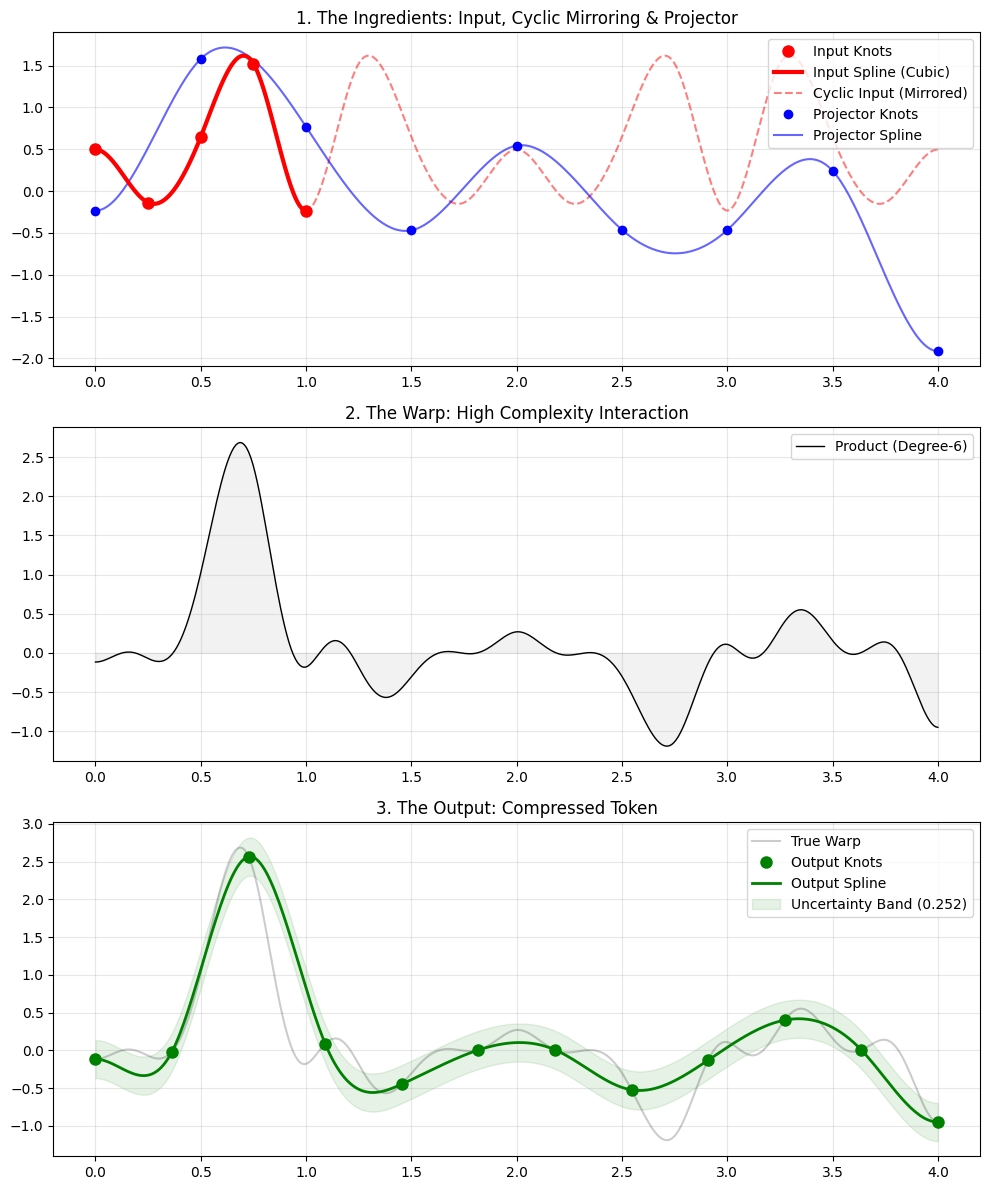

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

class Curve:
    def __init__(self, x, y, bc_type='natural'):
        self.knots_x = x
        self.knots_y = y
        self.spline = CubicSpline(x, y, bc_type=bc_type)

    def __call__(self, x):
        return self.spline(x)

def generate_clamped_curve(n_knots, domain=(0, 1)):
    x = np.linspace(domain[0], domain[1], n_knots)
    y = np.random.randn(n_knots)
    return Curve(x, y, bc_type=((1, 0.0), (1, 0.0)))

def create_smooth_cyclic_input(input_curve, repeats, mirror=True):
    samples_per_tile = 100
    x_local = np.linspace(0, 1, samples_per_tile)
    y_local = input_curve(x_local)

    full_x = []
    full_y = []

    for i in range(repeats):
        x_shift = x_local + i

        if mirror and (i % 2 == 1):
            y_tile = y_local[::-1]
        else:
            y_tile = y_local

        if i > 0:
            full_x.append(x_shift[1:])
            full_y.append(y_tile[1:])
        else:
            full_x.append(x_shift)
            full_y.append(y_tile)

    return np.concatenate(full_x), np.concatenate(full_y)

def warp_and_refit(cyclic_x, cyclic_y, projector_curve, output_knots):
    projector_y = projector_curve(cyclic_x)
    product_y = cyclic_y * projector_y
    new_knots_x = np.linspace(cyclic_x[0], cyclic_x[-1], output_knots)
    new_knots_y = np.interp(new_knots_x, cyclic_x, product_y)
    output_curve = Curve(new_knots_x, new_knots_y, bc_type=((1, 0.0), (1, 0.0)))
    reconstructed_y = output_curve(cyclic_x)
    residual = np.abs(product_y - reconstructed_y)
    uncertainty = np.mean(residual)
    return output_curve, uncertainty, cyclic_x, product_y

# EXECUTION
np.random.seed(42)
N_KNOTS = 5
M_REPEATS = 4
input_token = generate_clamped_curve(N_KNOTS)
projector = generate_clamped_curve(M_REPEATS * 2 + 1, domain=(0, M_REPEATS))
cyclic_x, cyclic_y = create_smooth_cyclic_input(input_token, M_REPEATS, mirror=True)
output_token, uncertainty, prod_x, prod_y = warp_and_refit(cyclic_x, cyclic_y, projector, output_knots=12)

# VISUALIZATION UPDATE
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# Plot 1: Ingredients + Mirrored Signal
dense_x = np.linspace(0, 1, 100)
# Original Token
axes[0].plot(input_token.knots_x, input_token.knots_y, 'ro', markersize=8, zorder=5, label="Input Knots")
axes[0].plot(dense_x, input_token(dense_x), 'r-', linewidth=3, alpha=1.0, zorder=4, label="Input Spline (Cubic)")
# Mirrored Signal (New Addition)
axes[0].plot(cyclic_x, cyclic_y, 'r--', linewidth=1.5, alpha=0.5, label="Cyclic Input (Mirrored)")
# Projector
p_dense_x = np.linspace(0, M_REPEATS, 400)
axes[0].plot(projector.knots_x, projector.knots_y, 'bo', markersize=6, zorder=5, label="Projector Knots")
axes[0].plot(p_dense_x, projector(p_dense_x), 'b-', linewidth=1.5, alpha=0.6, zorder=3, label="Projector Spline")

axes[0].set_title("1. The Ingredients: Input, Cyclic Mirroring & Projector")
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Plot 2: Warp
axes[1].plot(prod_x, prod_y, 'k-', linewidth=1, label="Product (Degree-6)")
axes[1].fill_between(prod_x, prod_y, color='black', alpha=0.05)
axes[1].set_title("2. The Warp: High Complexity Interaction")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Output
axes[2].plot(prod_x, prod_y, 'k-', alpha=0.2, label="True Warp")
axes[2].plot(output_token.knots_x, output_token.knots_y, 'go', markersize=8, label="Output Knots")
out_dense_x = np.linspace(0, M_REPEATS, 400)
axes[2].plot(out_dense_x, output_token(out_dense_x), 'g-', linewidth=2, label="Output Spline")
upper = output_token(out_dense_x) + uncertainty
lower = output_token(out_dense_x) - uncertainty
axes[2].fill_between(out_dense_x, lower, upper, color='green', alpha=0.1, label=f"Uncertainty Band ({uncertainty:.3f})")
axes[2].set_title("3. The Output: Compressed Token")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('spline_interaction_viz_mirrored.png')

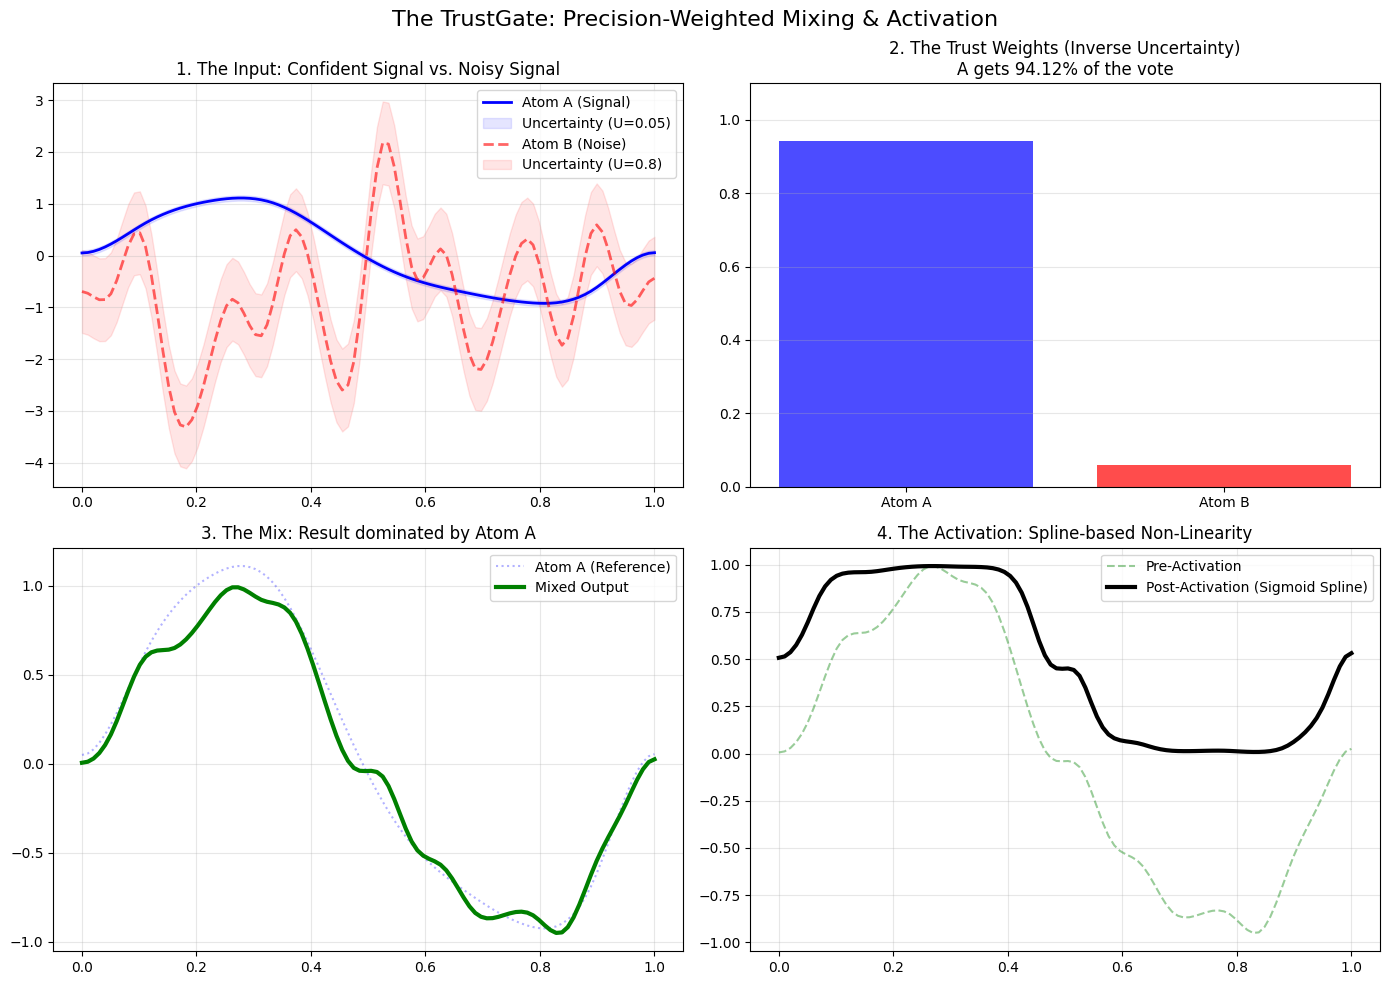

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# ==========================================
# 1. CORE CLASSES
# ==========================================
class Curve:
    def __init__(self, x, y, bc_type='natural'):
        self.knots_x = x
        self.knots_y = y
        self.spline = CubicSpline(x, y, bc_type=bc_type)

    def __call__(self, x):
        return self.spline(x)

def generate_signal(n_knots=10, noise_level=0.1):
    x = np.linspace(0, 1, n_knots)
    y = np.sin(2 * np.pi * x) + np.random.randn(n_knots) * noise_level
    # Clamp ends to 0 for C1 continuity
    return Curve(x, y, bc_type=((1, 0.0), (1, 0.0)))

def generate_noise(n_knots=20):
    x = np.linspace(0, 1, n_knots)
    y = np.random.randn(n_knots) * 1.5 # High amplitude noise
    return Curve(x, y, bc_type=((1, 0.0), (1, 0.0)))

# ==========================================
# 2. TRUST GATE LOGIC (Precision-Weighted Mixing)
# ==========================================
def precision_weighted_mix(signals_data, domain_x):
    """
    signals_data: List of tuples (Curve, Uncertainty)
    domain_x: Points to evaluate the mixing at
    """
    numerator = np.zeros_like(domain_x)
    denominator = 0.0

    weights_log = []

    for curve, u in signals_data:
        # Avoid divide by zero
        epsilon = 1e-6

        # Precision = 1 / Variance (roughly)
        # Trust = 1 / Uncertainty
        trust = 1.0 / (u + epsilon)

        y_vals = curve(domain_x)

        # Weighted Sum
        numerator += y_vals * trust
        denominator += trust

        weights_log.append(trust)

    # Normalization (Softmax-like behavior)
    mixed_y = numerator / denominator

    # Calculate effective weights for logging
    total_trust = sum(weights_log)
    normalized_weights = [w / total_trust for w in weights_log]

    return mixed_y, normalized_weights

# ==========================================
# 3. SPLINE ACTIVATION (Learned Non-Linearity)
# ==========================================
def spline_activation(y_vals, mode='softmax'):
    """
    Simulates a learnable spline initialized to a specific function.
    mode='softmax' -> Sigmoid-like (Suppress low, boost high)
    mode='identity' -> Linear (Pass-through)
    """
    if mode == 'softmax':
        # Sigmoid-like scaling
        return 1 / (1 + np.exp(-5 * y_vals)) # Steep sigmoid
    elif mode == 'identity':
        return y_vals
    return y_vals

# ==========================================
# 4. EXECUTION
# ==========================================
np.random.seed(42)

# Generate Agents
# Agent A: Confident Signal (Low U)
curve_a = generate_signal(noise_level=0.1)
u_a = 0.05

# Agent B: Confused Noise (High U)
curve_b = generate_noise()
u_b = 0.80

domain = np.linspace(0, 1, 100)
mixed_y, weights = precision_weighted_mix([(curve_a, u_a), (curve_b, u_b)], domain)

# Apply Activation
activated_y = spline_activation(mixed_y, mode='softmax')

# ==========================================
# 5. VISUALIZATION
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.suptitle("The TrustGate: Precision-Weighted Mixing & Activation", fontsize=16)

# Plot A: The Raw Inputs (with Uncertainty Bands)
axes[0,0].plot(domain, curve_a(domain), 'b-', linewidth=2, label=f"Atom A (Signal)")
axes[0,0].fill_between(domain, curve_a(domain)-u_a, curve_a(domain)+u_a, color='blue', alpha=0.1, label=f"Uncertainty (U={u_a})")

axes[0,0].plot(domain, curve_b(domain), 'r--', linewidth=2, alpha=0.6, label=f"Atom B (Noise)")
axes[0,0].fill_between(domain, curve_b(domain)-u_b, curve_b(domain)+u_b, color='red', alpha=0.1, label=f"Uncertainty (U={u_b})")

axes[0,0].set_title("1. The Input: Confident Signal vs. Noisy Signal")
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)  # FIXED LINE

# Plot B: The Weights (Bar Chart)
labels = ['Atom A', 'Atom B']
colors = ['blue', 'red']
axes[0,1].bar(labels, weights, color=colors, alpha=0.7)
axes[0,1].set_title(f"2. The Trust Weights (Inverse Uncertainty)\nA gets {weights[0]:.2%} of the vote")
axes[0,1].set_ylim(0, 1.1)
axes[0,1].grid(axis='y', alpha=0.3)

# Plot C: The Mixed Result (Pre-Activation)
axes[1,0].plot(domain, curve_a(domain), 'b:', alpha=0.3, label="Atom A (Reference)")
axes[1,0].plot(domain, mixed_y, 'g-', linewidth=3, label="Mixed Output")
axes[1,0].set_title("3. The Mix: Result dominated by Atom A")
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot D: The Activation (Spline-Softmax)
axes[1,1].plot(domain, mixed_y, 'g--', alpha=0.4, label="Pre-Activation")
axes[1,1].plot(domain, activated_y, 'k-', linewidth=3, label="Post-Activation (Sigmoid Spline)")
axes[1,1].set_title("4. The Activation: Spline-based Non-Linearity")
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

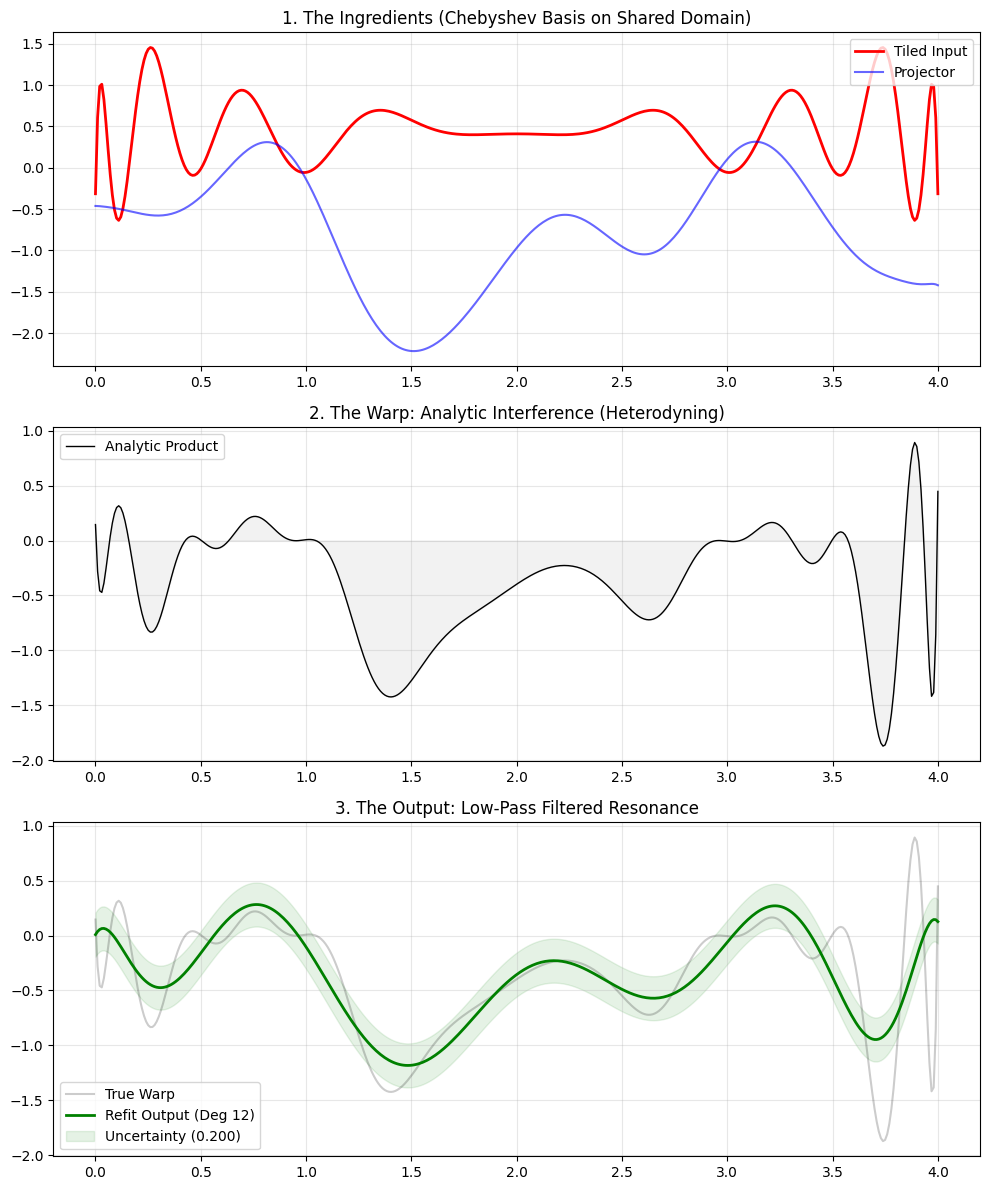

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from numpy.polynomial import Chebyshev

# --- HELPER: Generate Clamped Data (Ground Truth) ---
def generate_clamped_data(n_samples=100, domain=(0, 1)):
    # We use splines just to generate "Valid" physical data (Slope 0 at edges)
    x = np.linspace(domain[0], domain[1], 10)
    y = np.random.randn(10)
    # Enforce Clamped BCs
    spline = CubicSpline(x, y, bc_type=((1, 0.0), (1, 0.0)))

    dense_x = np.linspace(domain[0], domain[1], n_samples)
    return dense_x, spline(dense_x)

# --- CORE LOGIC: Chebyshev Atom ---
def fit_cheb(x, y, deg, domain):
    # FIXED: Parameter name changed to 'deg' to match call site
    return Chebyshev.fit(x, y, deg=deg, domain=domain)

def cheb_warp_and_refit(input_cheb, projector_cheb, output_degree):
    # 1. The Analytic Warp (The Physics)
    # Numpy handles the "Product Identity" automatically.
    # Degree(Product) = Degree(Input) + Degree(Projector)
    warp_cheb = input_cheb * projector_cheb

    # 2. The Refit (The Compression)
    # We sample the high-degree warp and fit a lower-degree basis
    # This acts as the Low-Pass Filter
    domain = warp_cheb.domain
    x_sample = np.linspace(domain[0], domain[1], 100)
    y_true_warp = warp_cheb(x_sample)

    output_cheb = Chebyshev.fit(x_sample, y_true_warp, deg=output_degree, domain=domain)

    # 3. Uncertainty (Residual Energy)
    y_reconstructed = output_cheb(x_sample)
    residual = np.mean(np.abs(y_true_warp - y_reconstructed))

    return output_cheb, warp_cheb, residual

# --- EXECUTION ---
np.random.seed(42)

# 1. Create Raw Input Data
x_data, y_data = generate_clamped_data(domain=(0, 1))

# 2. Tiling Logic
# We must tile the DATA first, then fit a Chebyshev on the FULL domain [0, M]
M_REPEATS = 4
tile_x_list = []
tile_y_list = []
for i in range(M_REPEATS):
    # Mirroring Logic
    y_tile = y_data if i % 2 == 0 else y_data[::-1]
    tile_x_list.append(x_data + i)
    tile_y_list.append(y_tile)

full_x = np.concatenate(tile_x_list)
full_y = np.concatenate(tile_y_list)

# 3. Create Ingredients on Shared Domain [0, M_REPEATS]
# Input: Represents the "Subject" repeated M times
tiled_input_token = fit_cheb(full_x, full_y, deg=20, domain=(0, M_REPEATS))

# Projector: Represents the "Filter" spanning M tiles
# We generate new random projector data on the full domain
p_x, p_y = generate_clamped_data(n_samples=400, domain=(0, M_REPEATS))
projector = fit_cheb(p_x, p_y, deg=20, domain=(0, M_REPEATS))

# 4. Run Atom Logic
# Now both share domain [0, 4], so multiplication works
output_token, true_warp, uncertainty = cheb_warp_and_refit(tiled_input_token, projector, output_degree=12)


# --- VISUALIZATION ---
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# Plot 1: The Ingredients (Spectral)
dense_x = np.linspace(0, M_REPEATS, 400)
axes[0].plot(dense_x, tiled_input_token(dense_x), 'r-', linewidth=2, label=f"Tiled Input")
axes[0].plot(dense_x, projector(dense_x), 'b-', alpha=0.6, label=f"Projector")
axes[0].set_title("1. The Ingredients (Chebyshev Basis on Shared Domain)")
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Plot 2: The Analytic Warp
# Note: This curve is mathematically exact, not an interpolation
warp_x = np.linspace(0, M_REPEATS, 400)
axes[1].plot(warp_x, true_warp(warp_x), 'k-', linewidth=1, label=f"Analytic Product")
axes[1].fill_between(warp_x, true_warp(warp_x), color='black', alpha=0.05)
axes[1].set_title("2. The Warp: Analytic Interference (Heterodyning)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: The Filtered Output
axes[2].plot(warp_x, true_warp(warp_x), 'k-', alpha=0.2, label="True Warp")
axes[2].plot(warp_x, output_token(warp_x), 'g-', linewidth=2, label=f"Refit Output (Deg 12)")
axes[2].fill_between(warp_x,
                     output_token(warp_x) - uncertainty,
                     output_token(warp_x) + uncertainty,
                     color='green', alpha=0.1, label=f"Uncertainty ({uncertainty:.3f})")
axes[2].set_title("3. The Output: Low-Pass Filtered Resonance")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# temp

Generating Optimization Proof...


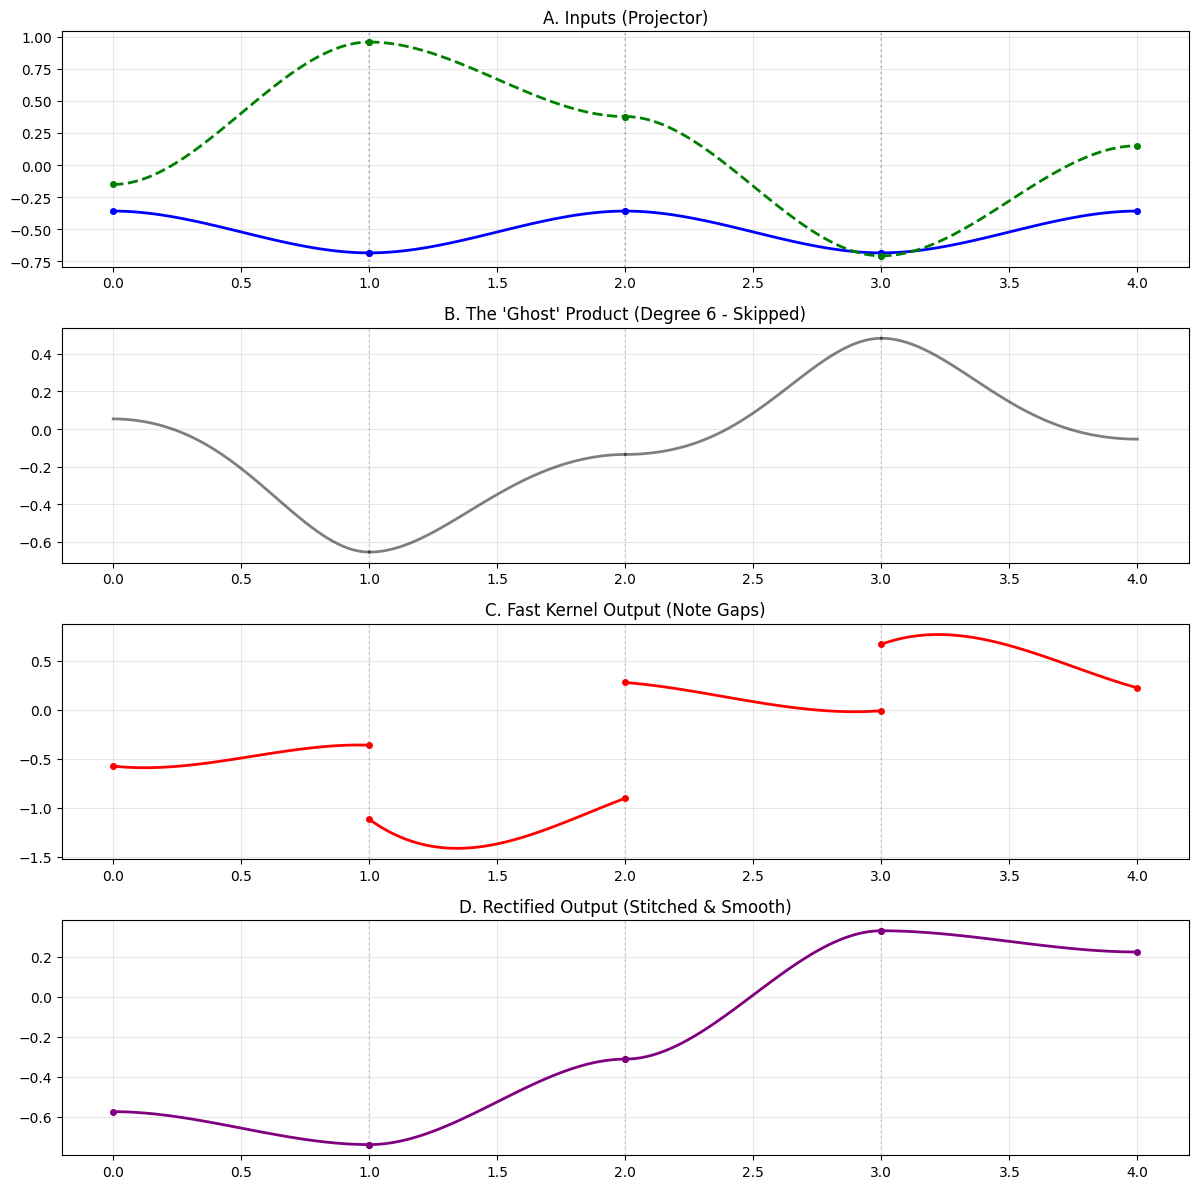

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. GEOMETRY & STITCHING
# ==========================================

class UnitCurve:
    def __init__(self, knots):
        self.knots = knots

    def enforce_smoothness(self):
        # Forces zero-slope tangents at endpoints
        p0 = self.knots[..., 0:1]
        p3 = self.knots[..., 3:4]
        # Overwrite handles P1 and P2
        return UnitCurve(torch.cat([p0, p0, p3, p3], dim=-1))

class CurveChain:
    def __init__(self, num_units, label="Chain"):
        self.num_units = num_units
        self.label = label

        # Initialize Connected Chain
        # 1. Generate Anchors (Shared Junctions)
        anchors = torch.rand(1, 1, num_units + 1) * 2 - 1

        # 2. Build Units
        units_list = []
        for i in range(num_units):
            # Start/End for this unit come from shared anchors
            start = anchors[:, :, i:i+1]
            end   = anchors[:, :, i+1:i+2]

            # Create Raw Unit
            raw = torch.cat([start, start, end, end], dim=-1)
            # Enforce zero-slopes immediately
            units_list.append(UnitCurve(raw).enforce_smoothness().knots)

        self.data = torch.stack(units_list, dim=1) # (B, Units, Chan, 4)

    @staticmethod
    def stitch(chain_tensor):
        """
        The Topological Fix.
        Averages the boundary points between neighbors to snap the gap.
        Input: (Batch, Units, Chan, 4)
        """
        B, U, C, N = chain_tensor.shape
        if U < 2: return chain_tensor

        # Clone to avoid in-place issues during calc
        stitched = chain_tensor.clone()

        # Iterate through junctions
        for i in range(U - 1):
            # End of Unit i
            end_val = stitched[:, i, :, 3]
            # Start of Unit i+1
            start_val = stitched[:, i+1, :, 0]

            # Average
            junction_mean = (end_val + start_val) / 2.0

            # Snap both to mean
            stitched[:, i, :, 3] = junction_mean
            stitched[:, i+1, :, 0] = junction_mean

        return stitched

# ==========================================
# 2. PHYSICS (Fast Kernel + Stitching)
# ==========================================

class SpectralAlgebra:
    @staticmethod
    def build_kernel(degree=3):
        n = degree + 1
        k = torch.zeros(n, n, n)
        for i in range(n):
            for j in range(n):
                if i+j < n: k[i+j, i, j] += 0.5
                if abs(i-j) < n: k[abs(i-j), i, j] += 0.5
        return k

    @staticmethod
    def mix_optimized(input_chain, projector_chain, kernel):
        # 1. Tiling
        in_units = input_chain.shape[1]
        proj_units = projector_chain.shape[1]

        if in_units < proj_units:
            ratio = proj_units // in_units
            normal = input_chain
            flipped = torch.flip(input_chain, dims=[-1])
            tiles = [normal if i%2==0 else flipped for i in range(ratio)]
            tiled_input = torch.cat(tiles, dim=1)
            target = projector_chain
        else:
            tiled_input = input_chain
            target = projector_chain

        # 2. FAST MIX (The Approximation)
        # Direct 4x4x4 kernel. Independent per unit. Creates gaps.
        fast_result = torch.einsum('bucn, bucm, knm -> buck', tiled_input, target, kernel)

        # 3. RECTIFICATION (Stitch + Flatten)
        # A. Stitch: Snap the values together (C0 Continuity)
        stitched_result = CurveChain.stitch(fast_result)

        # B. Flatten: Enforce zero tangents (C1 Continuity)
        # We flatten the units to apply UnitCurve logic
        B, U, C, N = stitched_result.shape
        flat_res = stitched_result.view(-1, C, N)
        rectified_flat = UnitCurve(flat_res).enforce_smoothness().knots
        rectified_result = rectified_flat.view(B, U, C, N)

        return tiled_input, target, fast_result, rectified_result

# ==========================================
# 3. VISUALIZATION PROOF
# ==========================================

def run_proof():
    print("Generating Optimization Proof...")

    # 1. Setup
    input_token = CurveChain(num_units=1, label="Input")
    projector = CurveChain(num_units=4, label="Projector")
    kernel = SpectralAlgebra.build_kernel(3)

    # 2. Run Physics
    tiled_in, proj, fast_res, rect_res = SpectralAlgebra.mix_optimized(
        input_token.data, projector.data, kernel
    )

    # 3. Plotting
    plt.figure(figsize=(12, 12))

    def plot_chain(ax, data, title, color, style='-', show_dots=True):
        units = data[0]
        for i in range(units.shape[0]):
            knots = units[i, 0, :]
            t = torch.linspace(0, 1, 50)
            p0, p1, p2, p3 = knots[0], knots[1], knots[2], knots[3]
            curve = (1-t)**3*p0 + 3*(1-t)**2*t*p1 + 3*(1-t)*t**2*p2 + t**3*p3

            ax.plot(t + i, curve, color=color, linestyle=style, linewidth=2)

            if show_dots:
                # Plot Anchors
                ax.plot(i, knots[0], 'o', color=color, markersize=4)
                ax.plot(i+1, knots[3], 'o', color=color, markersize=4)

            if i > 0: ax.axvline(x=i, color='k', linestyle=':', alpha=0.1)

        ax.set_title(title)
        ax.grid(True, alpha=0.3)

    # Panel A: Inputs
    ax1 = plt.subplot(4, 1, 1)
    plot_chain(ax1, tiled_in, "A. Inputs (Tiled)", 'blue')
    plot_chain(ax1, proj, "A. Inputs (Projector)", 'green', style='--')

    # Panel B: The "Ghost" Product (Simulation)
    ax2 = plt.subplot(4, 1, 2)
    for i in range(4):
        # Simulate High-Res Product just for Viz
        ki = tiled_in[0, i, 0, :]
        kp = proj[0, i, 0, :]
        ti = torch.linspace(0, 1, 50)
        ci = (1-ti)**3*ki[0] + 3*(1-ti)**2*ti*ki[1] + 3*(1-ti)*ti**2*ki[2] + ti**3*ki[3]
        cp = (1-ti)**3*kp[0] + 3*(1-ti)**2*ti*kp[1] + 3*(1-ti)*ti**2*kp[2] + ti**3*kp[3]
        ax2.plot(ti + i, ci * cp, 'k-', alpha=0.5, linewidth=2)
        if i > 0: ax2.axvline(x=i, color='k', linestyle=':', alpha=0.1)
    ax2.set_title("B. The 'Ghost' Product (Degree 6 - Skipped)")
    ax2.grid(True, alpha=0.3)

    # Panel C: Fast Kernel Output (Gaps)
    ax3 = plt.subplot(4, 1, 3)
    plot_chain(ax3, fast_res, "C. Fast Kernel Output (Note Gaps)", 'red')

    # Panel D: Rectified Output (Stitched)
    ax4 = plt.subplot(4, 1, 4)
    plot_chain(ax4, rect_res, "D. Rectified Output (Stitched & Smooth)", 'purple')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_proof()

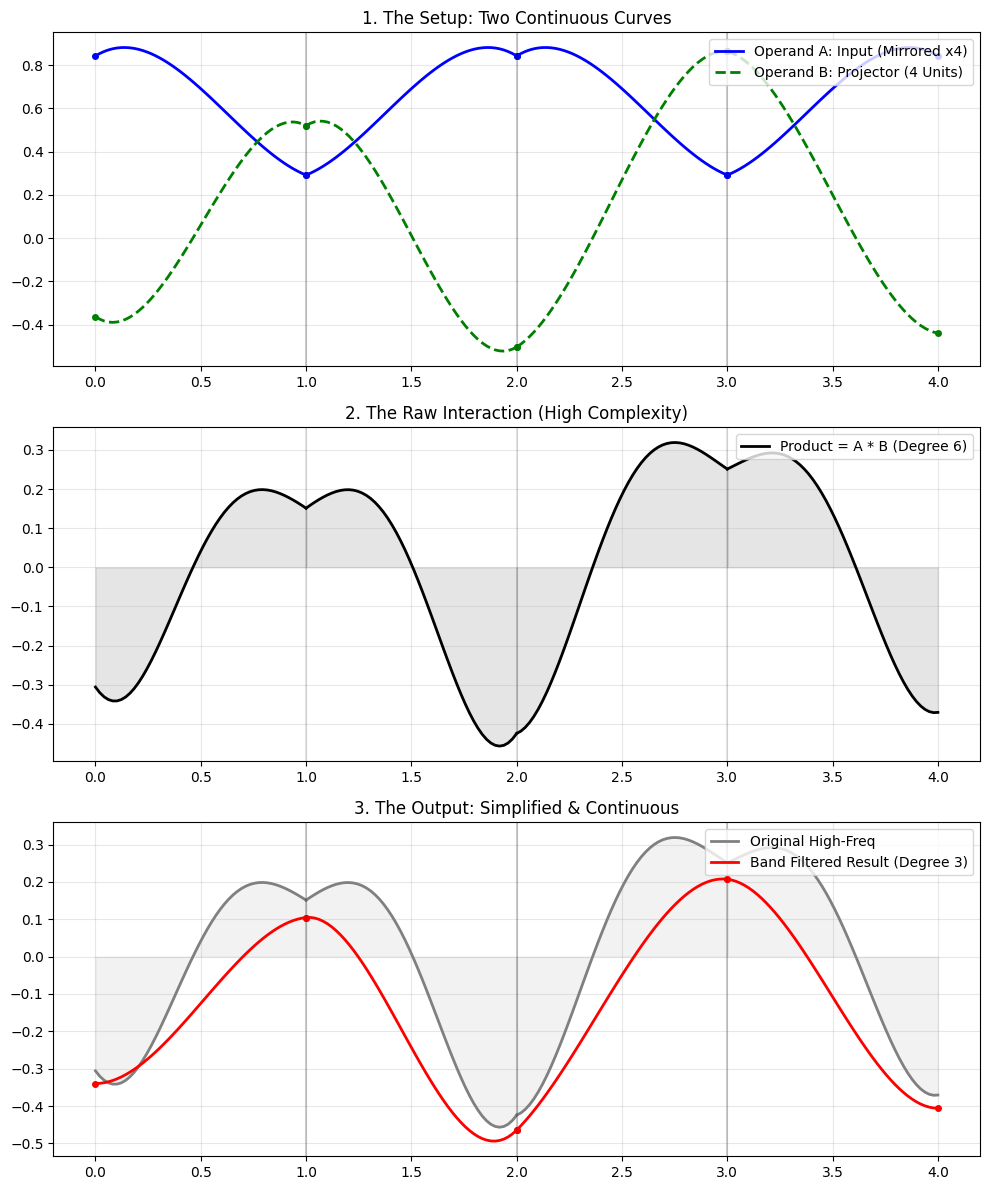

In [ ]:

import torch
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. GEOMETRY UTILS
# ==========================================
class UnitCurve:
    def __init__(self, knots):
        self.knots = knots

class CurveChain:
    def __init__(self, num_units, label=""):
        # Generate random continuous chain
        anchors = torch.rand(1, 1, num_units + 1) * 2 - 1
        units_list = []
        for i in range(num_units):
            start = anchors[:, :, i:i+1]
            end   = anchors[:, :, i+1:i+2]
            # Random handles
            h1 = start + (torch.rand_like(start) * 0.5 - 0.25)
            h2 = end + (torch.rand_like(end) * 0.5 - 0.25)
            raw = torch.cat([start, h1, h2, end], dim=-1)
            units_list.append(raw)
        self.data = torch.stack(units_list, dim=1)

    @staticmethod
    def stitch_c1(chain_tensor):
        """Enforces smoothness (C1) on a chain."""
        stitched = chain_tensor.clone()
        B, U, C, N = stitched.shape
        for i in range(U - 1):
            # C0: Snap Values
            mean = (stitched[:, i, :, 3] + stitched[:, i+1, :, 0]) / 2.0
            stitched[:, i, :, 3] = mean
            stitched[:, i+1, :, 0] = mean

            # C1: Align Tangents
            p2_left = stitched[:, i, :, 2]
            p1_right = stitched[:, i+1, :, 1]
            vec_left = mean - p2_left
            vec_right = p1_right - mean
            avg_tangent = (vec_left + vec_right) / 2.0

            stitched[:, i, :, 2] = mean - avg_tangent
            stitched[:, i+1, :, 1] = mean + avg_tangent

        # Global Ends (Zero Slope)
        stitched[:, 0, :, 1] = stitched[:, 0, :, 0]
        stitched[:, -1, :, 2] = stitched[:, -1, :, 3]
        return stitched

# ==========================================
# 2. FULL MATH ENGINE
# ==========================================
def run_full_math_process(tiled_in, projector):
    U = tiled_in.shape[1]

    # 1. High Res Expansion (Degree 6)
    dense_product_list = []

    # We use 50 samples per unit to capture high freq details
    t = torch.linspace(0, 1, 50)
    # Cubic Basis
    B = torch.stack([(1-t)**3, 3*(1-t)**2*t, 3*(1-t)*t**2, t**3]).T

    for i in range(U):
        k_in = tiled_in[0, i, 0, :]
        k_proj = projector[0, i, 0, :]

        y_in = torch.matmul(B, k_in)
        y_proj = torch.matmul(B, k_proj)

        # The Complex Product
        y_product = y_in * y_proj
        dense_product_list.append(y_product)

    # 2. Band Filtering (Global Reduction)
    # We fit Degree 3 curves back to this Degree 6 data
    fit_matrix = torch.linalg.pinv(B)
    truth_units = []
    for i in range(U):
        knots_fit = torch.matmul(fit_matrix, dense_product_list[i])
        truth_units.append(knots_fit)

    raw_fit = torch.stack(truth_units).view(1, U, 1, 4)

    # 3. Post-Process: C1 Continuity
    final_smooth = CurveChain.stitch_c1(raw_fit)

    return dense_product_list, final_smooth

# ==========================================
# 3. VISUALIZATION
# ==========================================
def run_demo():
    # Setup: 4 Units total
    # Input is 1 unit, Projector is 4 units.
    input_chain = CurveChain(num_units=1)
    proj_chain = CurveChain(num_units=4)

    # Create 4 Mirror Tiles
    normal = input_chain.data
    flipped = torch.flip(input_chain.data, dims=[-1])
    # Pattern: Normal -> Flip -> Normal -> Flip
    tiled_in = torch.cat([normal, flipped, normal, flipped], dim=1)

    # Run Physics
    high_freq_product, final_result = run_full_math_process(tiled_in, proj_chain.data)

    # Plotting
    fig, axes = plt.subplots(3, 1, figsize=(10, 12))

    def plot_curve(ax, knots, color, label, style='-'):
        units = knots[0]
        for i in range(units.shape[0]):
            k = units[i, 0, :]
            t = torch.linspace(0, 1, 50)
            c = (1-t)**3*k[0] + 3*(1-t)**2*t*k[1] + 3*(1-t)*t**2*k[2] + t**3*k[3]

            lbl = label if i==0 else ""
            ax.plot(t + i, c, color=color, linestyle=style, linewidth=2, label=lbl)

            # Draw Anchor Dots
            ax.plot([i, i+1], [k[0], k[3]], 'o', color=color, markersize=4)

            # Grid line
            if i > 0: ax.axvline(x=i, color='k', alpha=0.1)

    def plot_dense(ax, dense_list, color, label):
        for i, y in enumerate(dense_list):
            t = torch.linspace(0, 1, len(y))
            lbl = label if i==0 else ""
            ax.plot(t + i, y, color=color, linewidth=2, label=lbl)
            ax.fill_between(t + i, y, color=color, alpha=0.1)
            if i > 0: ax.axvline(x=i, color='k', alpha=0.1)

    # PLOT 1: The Operands
    plot_curve(axes[0], tiled_in, 'blue', "Operand A: Input (Mirrored x4)")
    plot_curve(axes[0], proj_chain.data, 'green', "Operand B: Projector (4 Units)", style='--')
    axes[0].set_title("1. The Setup: Two Continuous Curves")
    axes[0].legend(loc="upper right")
    axes[0].grid(True, alpha=0.3)

    # PLOT 2: The Raw Interaction
    plot_dense(axes[1], high_freq_product, 'black', "Product = A * B (Degree 6)")
    axes[1].set_title("2. The Raw Interaction (High Complexity)")
    axes[1].legend(loc="upper right")
    axes[1].grid(True, alpha=0.3)

    # PLOT 3: The Result
    # Compare Raw (faint) vs Smooth Result (Solid)
    plot_dense(axes[2], high_freq_product, 'gray', "Original High-Freq")
    plot_curve(axes[2], final_result, 'red', "Band Filtered Result (Degree 3)")
    axes[2].set_title("3. The Output: Simplified & Continuous")
    axes[2].legend(loc="upper right")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_demo()

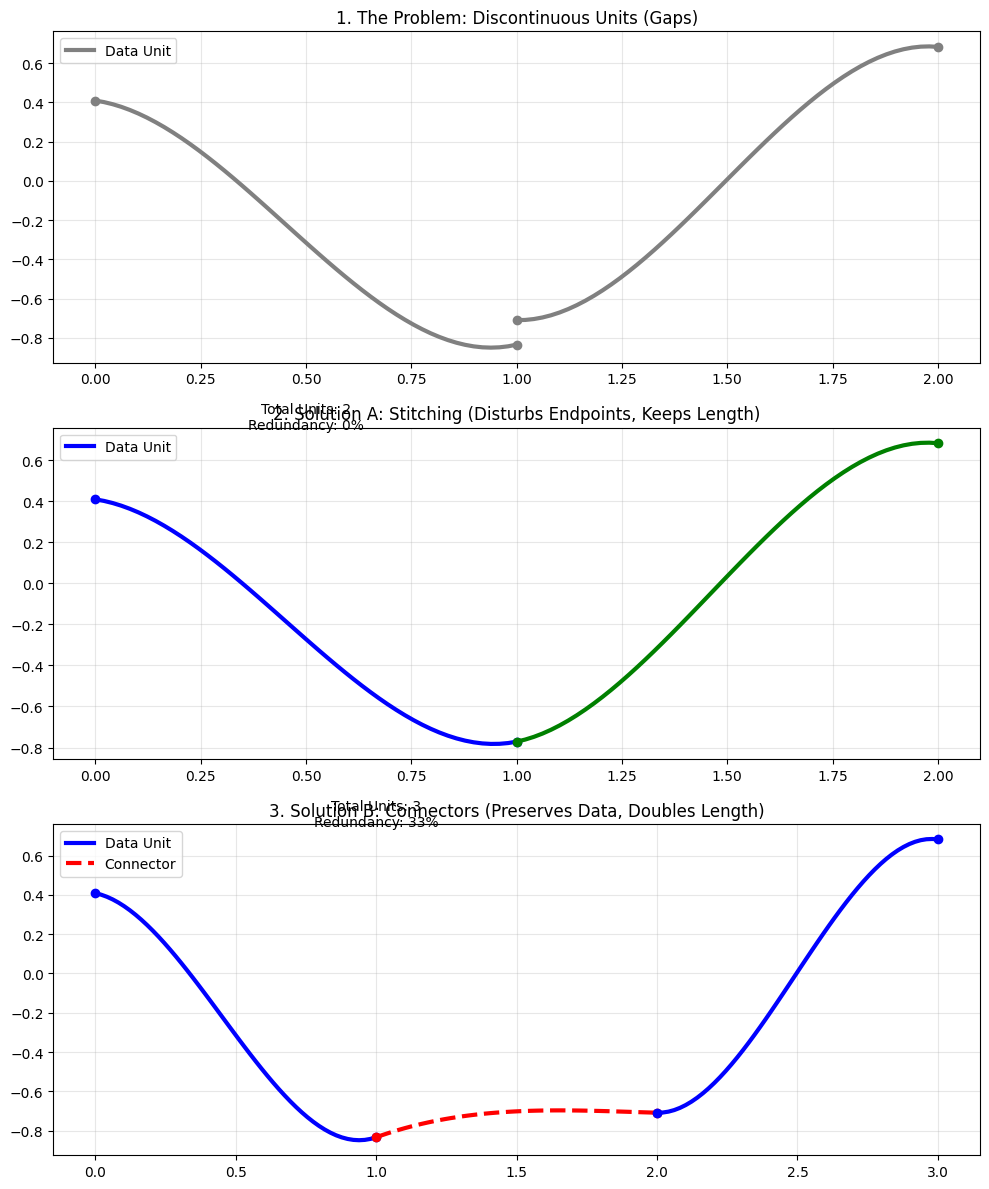

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. GEOMETRY UTILS
# ==========================================
class UnitCurve:
    def __init__(self, knots):
        self.knots = knots

class CurveChain:
    def __init__(self, num_units):
        # Discontinuous Chain
        anchors = torch.rand(1, 1, num_units + 1) * 2 - 1
        units_list = []
        for i in range(num_units):
            # Create independent segments with GAPS
            start = anchors[:, :, i:i+1] + (torch.rand(1,1,1)*0.5 - 0.25)
            end   = anchors[:, :, i+1:i+2] + (torch.rand(1,1,1)*0.5 - 0.25)

            # Random Handles
            h1 = start + (torch.rand_like(start) * 0.5 - 0.25)
            h2 = end + (torch.rand_like(end) * 0.5 - 0.25)

            raw = torch.cat([start, h1, h2, end], dim=-1)
            units_list.append(raw)
        self.data = torch.stack(units_list, dim=1)

    @staticmethod
    def stitch_c1(chain_tensor):
        """Current Method: Modify endpoints to fit."""
        stitched = chain_tensor.clone()
        B, U, C, N = stitched.shape
        for i in range(U - 1):
            # Average Values
            mean = (stitched[:, i, :, 3] + stitched[:, i+1, :, 0]) / 2.0
            stitched[:, i, :, 3] = mean
            stitched[:, i+1, :, 0] = mean

            # Average Tangents
            p2_left = stitched[:, i, :, 2]
            p1_right = stitched[:, i+1, :, 1]
            vec_l = mean - p2_left
            vec_r = p1_right - mean
            avg_tan = (vec_l + vec_r) / 2.0

            # Modify Segments
            stitched[:, i, :, 2] = mean - avg_tan
            stitched[:, i+1, :, 1] = mean + avg_tan
        return stitched

    @staticmethod
    def generate_connectors(chain_tensor):
        """Your Method: Insert bridging units."""
        B, U, C, N = chain_tensor.shape
        new_chain_list = []

        for i in range(U):
            # Add original unit (UNTOUCHED)
            current_unit = chain_tensor[:, i, :, :]
            new_chain_list.append(current_unit)

            # If not last unit, create connector
            if i < U - 1:
                next_unit = chain_tensor[:, i+1, :, :]

                # Connector Constraints
                # Start = End of Current
                P0 = current_unit[..., 3:4]
                # End = Start of Next
                P3 = next_unit[..., 0:1]

                # Tangent 1 (Match Current Outgoing)
                # T_out = P3 - P2 (of current)
                T_out = current_unit[..., 3:4] - current_unit[..., 2:3]
                P1 = P0 + T_out # Preserve slope magnitude/direction

                # Tangent 2 (Match Next Incoming)
                # T_in = P1 - P0 (of next)
                T_in = next_unit[..., 1:2] - next_unit[..., 0:1]
                P2 = P3 - T_in

                connector = torch.cat([P0, P1, P2, P3], dim=-1)
                new_chain_list.append(connector)

        return torch.stack(new_chain_list, dim=1)

# ==========================================
# 2. VISUALIZATION
# ==========================================
def compare_strategies():
    # Setup: 2 Units with a visible gap
    chain = CurveChain(num_units=2)

    # 1. Stitched
    stitched_data = CurveChain.stitch_c1(chain.data)

    # 2. Connected
    connected_data = CurveChain.generate_connectors(chain.data)

    # PLOT
    fig, axes = plt.subplots(3, 1, figsize=(10, 12))

    def plot_chain(ax, data, title, color_cycle=['blue', 'green', 'orange']):
        units = data[0]
        for i in range(units.shape[0]):
            k = units[i, 0, :]
            t = torch.linspace(0, 1, 50)
            c = (1-t)**3*k[0] + 3*(1-t)**2*t*k[1] + 3*(1-t)*t**2*k[2] + t**3*k[3]

            color = color_cycle[i % len(color_cycle)]
            # Highlight Connectors
            is_connector = (i % 2 != 0) and ("Connector" in title)
            if is_connector:
                color = 'red'
                label = "Connector" if i==1 else ""
                style = '--'
            else:
                label = "Data Unit" if i==0 else ""
                style = '-'

            ax.plot(t + i, c, color=color, linestyle=style, linewidth=3, label=label)
            ax.plot([i, i+1], [k[0], k[3]], 'o', color=color)

        ax.set_title(title)
        ax.legend()
        ax.grid(True, alpha=0.3)

    # Plot 1: Original
    plot_chain(axes[0], chain.data, "1. The Problem: Discontinuous Units (Gaps)", ['gray'])

    # Plot 2: Stitching
    plot_chain(axes[1], stitched_data, "2. Solution A: Stitching (Disturbs Endpoints, Keeps Length)", ['blue', 'green'])
    axes[1].text(0.5, stitched_data.max(), f"Total Units: 2\nRedundancy: 0%", ha='center')

    # Plot 3: Connectors
    plot_chain(axes[2], connected_data, "3. Solution B: Connectors (Preserves Data, Doubles Length)", ['blue', 'green'])
    axes[2].text(1.0, connected_data.max(), f"Total Units: 3\nRedundancy: 33%", ha='center')

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    compare_strategies()